# Employee Payroll — Base Pay Prediction

This notebook walks through a complete, beginner-friendly machine learning workflow using the **Employee Payroll** dataset (Cook County employee payroll records).

**Goal:** Predict an employee's **Base Pay** for a given fiscal period using information such as fiscal year, bureau/department, job title, and tenure.

Since `Base Pay` is a **continuous numeric value**, this is a **regression problem** (not classification). The notebook still follows every stage requested: data loading, EDA, cleaning, feature engineering, model comparison, evaluation, hyperparameter tuning, feature importance, final model training, and model saving with Joblib.

Every step below has a Markdown explanation cell followed by its own code cell.

## 1. Import Libraries

We import the core libraries used throughout the notebook:
- **Pandas / NumPy** for data handling
- **Matplotlib / Seaborn** for visualization
- **Scikit-learn** for preprocessing, modeling, and evaluation
- **XGBoost** for gradient boosted trees (used if the package is installed)
- **Joblib** for saving and loading the trained model pipeline

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
print('XGBoost available:', XGBOOST_AVAILABLE)

XGBoost available: True


## 2. Load the Dataset

We load the `Employee_Payroll.csv` file into a Pandas DataFrame. This dataset contains one row per employee per fiscal quarter, including the bureau/department they work in, their job title, their base pay for that period, and their original hire date.

In [2]:
df = pd.read_csv('Employee_Payroll.csv')
print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (234299, 15)


,Fiscal Year,Fiscal Quarter,Fiscal Period,First Name,Last Name,Middle Init,Bureau,Office,Office Name,Job Code,Job Title,Base Pay,Position ID,Employee Identifier,Original Hire Date
0,2016,1,2016Q1,AMRITH,AAKRE,K,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,20088.00,9510200,6ac7ba3e-d286-44f5-87a0-191dc415e23c,05/16/2005
1,2016,2,2016Q2,AMRITH,AAKRE,K,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,23436.00,9510200,6ac7ba3e-d286-44f5-87a0-191dc415e23c,05/16/2005
2,2016,3,2016Q3,AMRITH,AAKRE,K,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,20422.82,9510200,6ac7ba3e-d286-44f5-87a0-191dc415e23c,05/16/2005
3,2016,4,2016Q4,AMRITH,AAKRE,K,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,23904.80,9510200,6ac7ba3e-d286-44f5-87a0-191dc415e23c,05/16/2005
4,2017,1,2017Q1,AMRITH,AAKRE,K,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,20745.80,9510200,6ac7ba3e-d286-44f5-87a0-191dc415e23c,05/16/2005


## 3. Initial Data Overview

Before doing anything else, we look at:
- Column data types (`.info()`)
- Summary statistics for numeric columns (`.describe()`)
- The number of missing values per column

This tells us what cleaning and preprocessing will be needed.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234299 entries, 0 to 234298
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Fiscal Year          234299 non-null  int64  
 1   Fiscal Quarter       234299 non-null  int64  
 2   Fiscal Period        234299 non-null  object 
 3   First Name           234299 non-null  object 
 4   Last Name            234299 non-null  object 
 5   Middle Init          140887 non-null  object 
 6   Bureau               234299 non-null  object 
 7   Office               231115 non-null  float64
 8   Office Name          231115 non-null  object 
 9   Job Code             234299 non-null  int64  
 10  Job Title            234299 non-null  object 
 11  Base Pay             234295 non-null  float64
 12  Position ID          234299 non-null  int64  
 13  Employee Identifier  234299 non-null  object 
 14  Original Hire Date   234299 non-null  object 
dtypes: float64(2), in

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Fiscal Year,234299.0,NaN,NaN,NaN,2016.829005,0.768902,2016.0,2016.0,2017.0,2017.0,2018.0
Fiscal Quarter,234299.0,NaN,NaN,NaN,2.257381,1.09466,1.0,1.0,2.0,3.0,4.0
Fiscal Period,234299,10,2018Q1,26539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First Name,234299,6880,MICHAEL,4682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,234299,13251,JOHNSON,2051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Middle Init,140887,287,M,18266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bureau,234299,111,Bureau of Health,53903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Office,231115.0,NaN,NaN,NaN,2268.636778,1611.800171,1002.0,1239.0,1280.0,4890.0,4898.0
Office Name,231115,160,DEPARTMENT OF CORRECTIONS,40534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Code,234299.0,NaN,NaN,NaN,2236.125622,1926.398577,1.0,1172.0,1360.0,2381.0,8097.0


In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
Middle Init,93412,39.87
Office Name,3184,1.36
Office,3184,1.36
Base Pay,4,0.00
Fiscal Period,0,0.00
Fiscal Quarter,0,0.00
Fiscal Year,0,0.00
Bureau,0,0.00
Last Name,0,0.00
First Name,0,0.00


## 4. Exploratory Data Analysis (EDA)

We now explore the data visually to understand patterns before modeling.

### 4.1 Distribution of the Target Variable (`Base Pay`)
Understanding the shape of the target helps us decide whether transformations (like log-scaling) or outlier removal are needed.

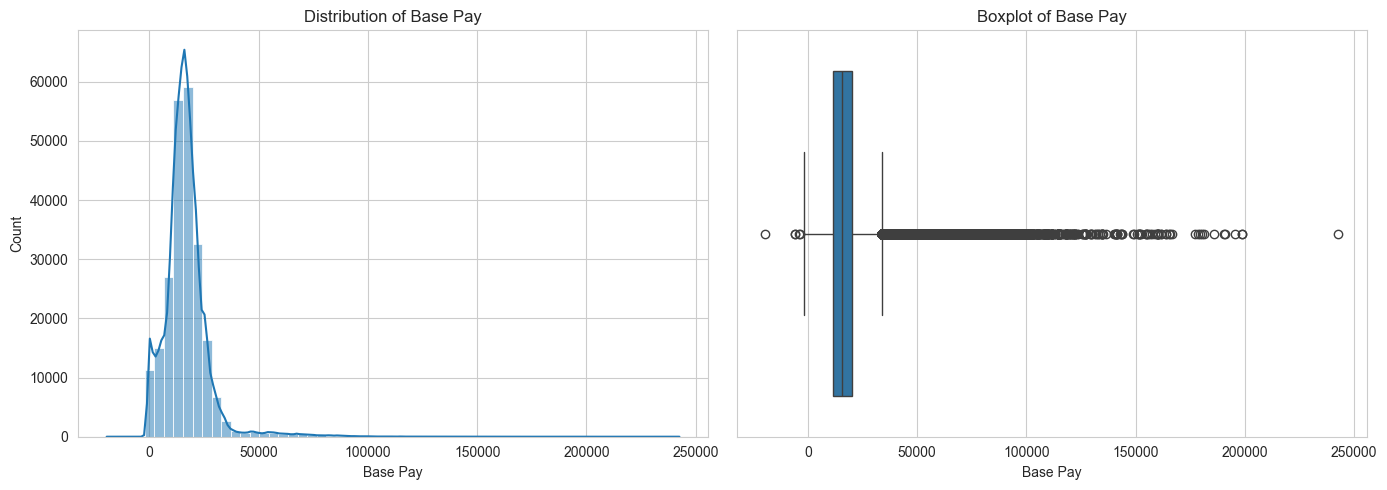

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Base Pay'].dropna(), bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Base Pay')
sns.boxplot(x=df['Base Pay'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot of Base Pay')
plt.tight_layout()
plt.show()

### 4.2 Base Pay by Fiscal Year
Do pay levels shift across the fiscal years covered by the dataset?

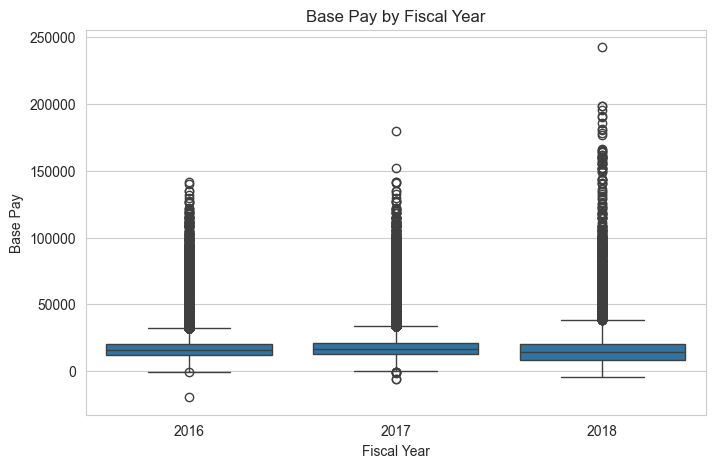

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fiscal Year', y='Base Pay')
plt.title('Base Pay by Fiscal Year')
plt.show()

### 4.3 Top Bureaus by Number of Records
Some bureaus (departments) employ far more people than others. This affects how much data we have to learn pay patterns for each bureau.

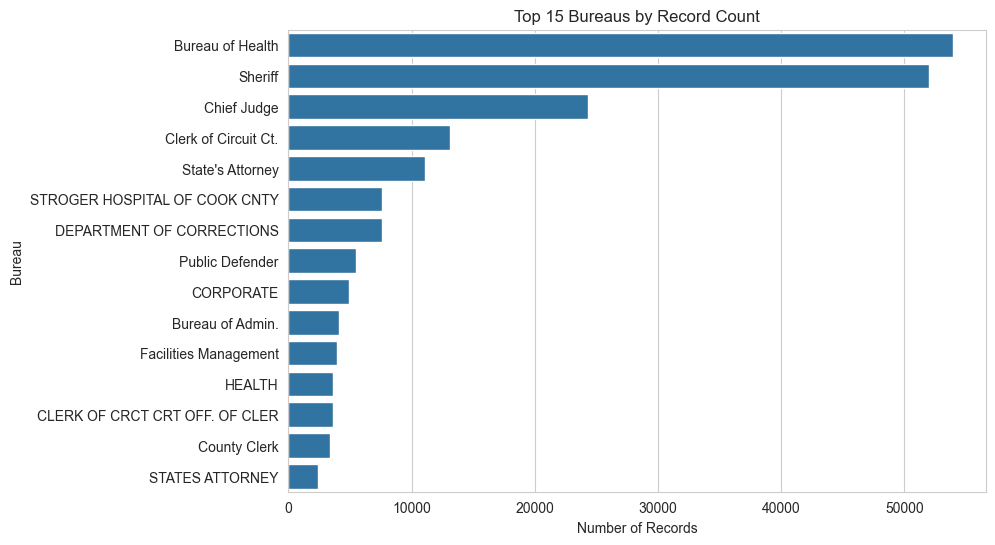

In [8]:
top_bureaus = df['Bureau'].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_bureaus.values, y=top_bureaus.index)
plt.xlabel('Number of Records')
plt.title('Top 15 Bureaus by Record Count')
plt.show()

### 4.4 Average Base Pay by Top Job Titles
Certain job titles are naturally associated with higher or lower pay. Visualizing this confirms `Job Title` is likely to be an important predictive feature.

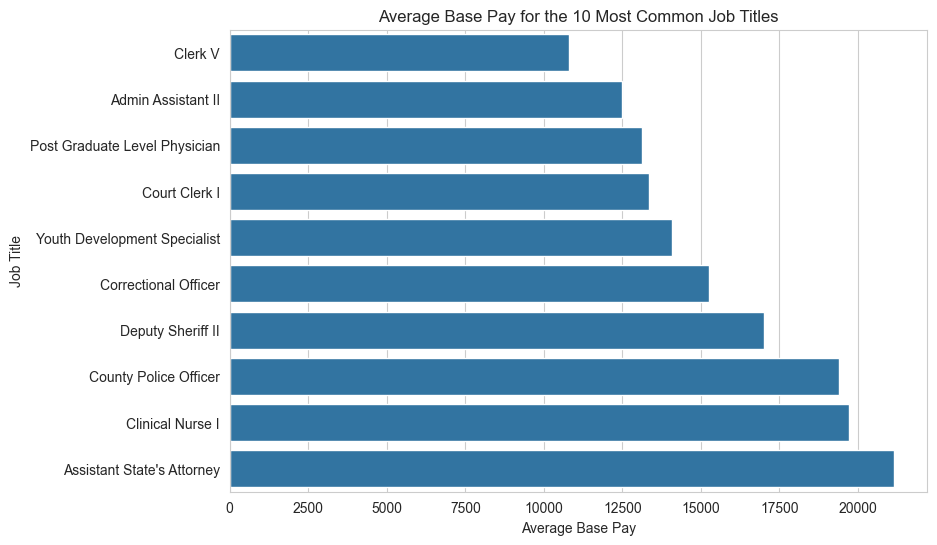

In [9]:
top_titles = df['Job Title'].value_counts().head(10).index
avg_pay_by_title = df[df['Job Title'].isin(top_titles)].groupby('Job Title')['Base Pay'].mean().sort_values()
plt.figure(figsize=(9, 6))
sns.barplot(x=avg_pay_by_title.values, y=avg_pay_by_title.index)
plt.xlabel('Average Base Pay')
plt.title('Average Base Pay for the 10 Most Common Job Titles')
plt.show()

### 4.5 Correlation Between Numeric Features
A correlation heatmap shows how numeric columns relate to each other and to `Base Pay`.

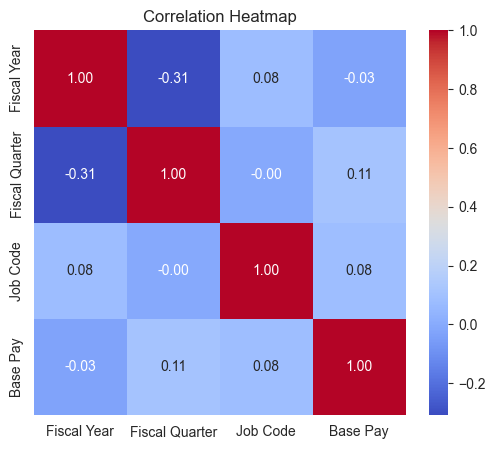

In [10]:
numeric_cols = ['Fiscal Year', 'Fiscal Quarter', 'Job Code', 'Base Pay']
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 5. Data Cleaning

Based on the EDA above, we perform the following cleaning steps:

1. **Drop rows with a missing `Base Pay`** — since this is our prediction target, rows without it cannot be used.
2. **Remove invalid pay values** — a small number of records have negative Base Pay, which is not physically meaningful (likely a data correction/reversal entry) and would distort the model.
3. **Drop identifier and free-text columns** that do not generalize (`First Name`, `Last Name`, `Middle Init`, `Employee Identifier`, `Position ID`, `Fiscal Period`). These uniquely identify a person or record rather than describing a general pattern, so keeping them would encourage the model to memorize individuals instead of learning transferable pay patterns.

In [11]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['Base Pay'])
df_clean = df_clean[df_clean['Base Pay'] >= 0]

columns_to_drop = ['First Name', 'Last Name', 'Middle Init', 'Employee Identifier', 'Position ID', 'Fiscal Period']
df_clean = df_clean.drop(columns=columns_to_drop)

print('Shape after cleaning:', df_clean.shape)
df_clean.head()

Shape after cleaning: (234273, 9)


,Fiscal Year,Fiscal Quarter,Bureau,Office,Office Name,Job Code,Job Title,Base Pay,Original Hire Date
0,2016,1,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,20088.00,05/16/2005
1,2016,2,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,23436.00,05/16/2005
2,2016,3,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,20422.82,05/16/2005
3,2016,4,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,23904.80,05/16/2005
4,2017,1,State's Attorney,1250.0,STATES ATTORNEY,1172,Assistant State's Attorney,20745.80,05/16/2005


## 6. Feature Engineering

We create and refine features that better capture patterns in the data:

1. **Tenure (years)** — calculated as `Fiscal Year - Year(Original Hire Date)`. This captures how experienced an employee is, which often correlates with pay.
2. **Reduce Job Title cardinality** — `Job Title` has thousands of unique values. To keep the model manageable and avoid extremely sparse categories, we keep the 30 most common job titles and group the rest into an `"Other"` category.
3. **Drop redundant columns** — `Office` (numeric code) is redundant with `Office Name`, and `Job Code` is redundant with `Job Title`, so we keep only the human-readable versions. `Original Hire Date` is dropped after `Tenure` is derived from it.

In [12]:
df_clean['Original Hire Date'] = pd.to_datetime(df_clean['Original Hire Date'], errors='coerce')
df_clean['Hire Year'] = df_clean['Original Hire Date'].dt.year
df_clean['Tenure'] = df_clean['Fiscal Year'] - df_clean['Hire Year']
df_clean['Tenure'] = df_clean['Tenure'].clip(lower=0)

top_job_titles = df_clean['Job Title'].value_counts().head(30).index
df_clean['Job Title Grouped'] = np.where(df_clean['Job Title'].isin(top_job_titles), df_clean['Job Title'], 'Other')

df_clean['Office Name'] = df_clean['Office Name'].fillna('Unknown')

df_model = df_clean.drop(columns=['Original Hire Date', 'Hire Year', 'Office', 'Job Code', 'Job Title'])

print('Shape after feature engineering:', df_model.shape)
df_model.head()

Shape after feature engineering: (234273, 7)


,Fiscal Year,Fiscal Quarter,Bureau,Office Name,Base Pay,Tenure,Job Title Grouped
0,2016,1,State's Attorney,STATES ATTORNEY,20088.00,11,Assistant State's Attorney
1,2016,2,State's Attorney,STATES ATTORNEY,23436.00,11,Assistant State's Attorney
2,2016,3,State's Attorney,STATES ATTORNEY,20422.82,11,Assistant State's Attorney
3,2016,4,State's Attorney,STATES ATTORNEY,23904.80,11,Assistant State's Attorney
4,2017,1,State's Attorney,STATES ATTORNEY,20745.80,12,Assistant State's Attorney


## 7. Defining the Problem Type

`Base Pay` is a continuous numeric variable, so this is a **regression task**. Our features are:

- **Numeric:** `Fiscal Year`, `Fiscal Quarter`, `Tenure`
- **Categorical:** `Bureau`, `Office Name`, `Job Title Grouped`

We will compare several regression algorithms, tune the best one, and save the final trained pipeline.

**Note on sample size:** the full dataset contains over 230,000 rows. To keep training times reasonable for a beginner-friendly notebook (especially for algorithms like SVR and KNN that scale poorly with data size), we train the model comparison stage on a random sample of the data. The final chosen model is then re-trained on a larger split for the best possible performance.

In [13]:
TARGET = 'Base Pay'
FEATURES = ['Fiscal Year', 'Fiscal Quarter', 'Tenure', 'Bureau', 'Office Name', 'Job Title Grouped']

SAMPLE_SIZE = 20000
df_sample = df_model.sample(n=min(SAMPLE_SIZE, len(df_model)), random_state=RANDOM_STATE)

X = df_sample[FEATURES]
y = df_sample[TARGET]

print('Sampled feature matrix shape:', X.shape)
X.head()

Sampled feature matrix shape: (20000, 6)


,Fiscal Year,Fiscal Quarter,Tenure,Bureau,Office Name,Job Title Grouped
130703,2016,1,4,Sheriff,DEPARTMENT OF CORRECTIONS,Correctional Officer
5219,2016,1,12,Bureau of Health,PROVIDENT HOSPITAL,Clerk V
156141,2016,3,25,Chief Judge,ADULT PROBATION DEPT.,Other
234188,2018,1,27,CLERK OF CRCT CRT OFF. OF CLER,CLERK OF CRCT CRT OFF. OF CLER,Court Clerk I
160721,2016,2,11,Clerk of Circuit Ct.,CLERK OF CRCT CRT OFF. OF CLER,Court Clerk I


## 8. Train-Test Split

We split the data into a **training set (80%)** and a **test set (20%)**. The model learns patterns only from the training set; the test set is held back to give an honest estimate of how well the model performs on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (16000, 6)
Test set size: (4000, 6)


## 9. Preprocessing Pipeline

We build a `ColumnTransformer` that applies different preprocessing to different column types:

- **Numeric columns** (`Fiscal Year`, `Fiscal Quarter`, `Tenure`): missing values filled with the median, then scaled with `StandardScaler` so all numeric features are on a comparable scale.
- **Categorical columns** (`Bureau`, `Office Name`, `Job Title Grouped`): missing values filled with the most frequent value, then converted to numeric form with `OneHotEncoder`.

Wrapping this in a `ColumnTransformer` (and later a full `Pipeline`) ensures the exact same preprocessing is applied consistently during training, testing, and future predictions.

In [15]:
numeric_features = ['Fiscal Year', 'Fiscal Quarter', 'Tenure']
categorical_features = ['Bureau', 'Office Name', 'Job Title Grouped']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 10. Model Training and Comparison

We train several regression models, each wrapped in a `Pipeline` with the shared preprocessing step:

- **Linear Regression** — a simple baseline that assumes a linear relationship between features and pay.
- **Decision Tree Regressor** — captures non-linear relationships by splitting data into branches.
- **Random Forest Regressor** — an ensemble of many decision trees, usually more accurate and stable than a single tree.
- **K-Nearest Neighbors Regressor** — predicts pay based on the average of the most similar employees in the training data.
- **Support Vector Regressor (SVR)** — finds a function that fits within a margin of tolerance around the true values.
- **Gradient Boosting Regressor** — builds trees sequentially, each one correcting the errors of the previous ones.
- **XGBoost Regressor** (if installed) — an optimized, high-performance implementation of gradient boosting.

Each model is trained on the training set and evaluated on the test set.

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)

trained_pipelines = {}
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    trained_pipelines[name] = pipeline
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2})

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,XGBoost,4990.305888,9.176534e+07,9579.422753,0.235072
1,Gradient Boosting,5367.422539,9.664463e+07,9830.800287,0.194400
2,Linear Regression,5426.492978,9.706189e+07,9851.999304,0.190921
3,K-Nearest Neighbors,5342.910066,1.049645e+08,10245.219749,0.125048
4,Random Forest,5378.856871,1.071229e+08,10350.021181,0.107056
5,Support Vector Machine,6543.042657,1.202759e+08,10967.037379,-0.002584
6,Decision Tree,6035.491819,1.359255e+08,11658.709146,-0.133034


## 11. Model Evaluation Metrics

Here is what each regression metric means:

- **MAE (Mean Absolute Error):** the average absolute difference between predicted and actual pay. Easy to interpret — it's in the same units as `Base Pay` (dollars).
- **MSE (Mean Squared Error):** the average of the squared differences between predicted and actual values. Squaring penalizes large errors more heavily than small ones.
- **RMSE (Root Mean Squared Error):** the square root of MSE, bringing the error back into the original dollar units while still penalizing large mistakes more than MAE does.
- **R² Score (Coefficient of Determination):** the proportion of variance in `Base Pay` that the model explains, ranging from 0 (no explanatory power) to 1 (perfect fit). A negative R² means the model performs worse than simply predicting the average.

Lower MAE/MSE/RMSE and higher R² indicate better performance. Let's visualize the comparison.

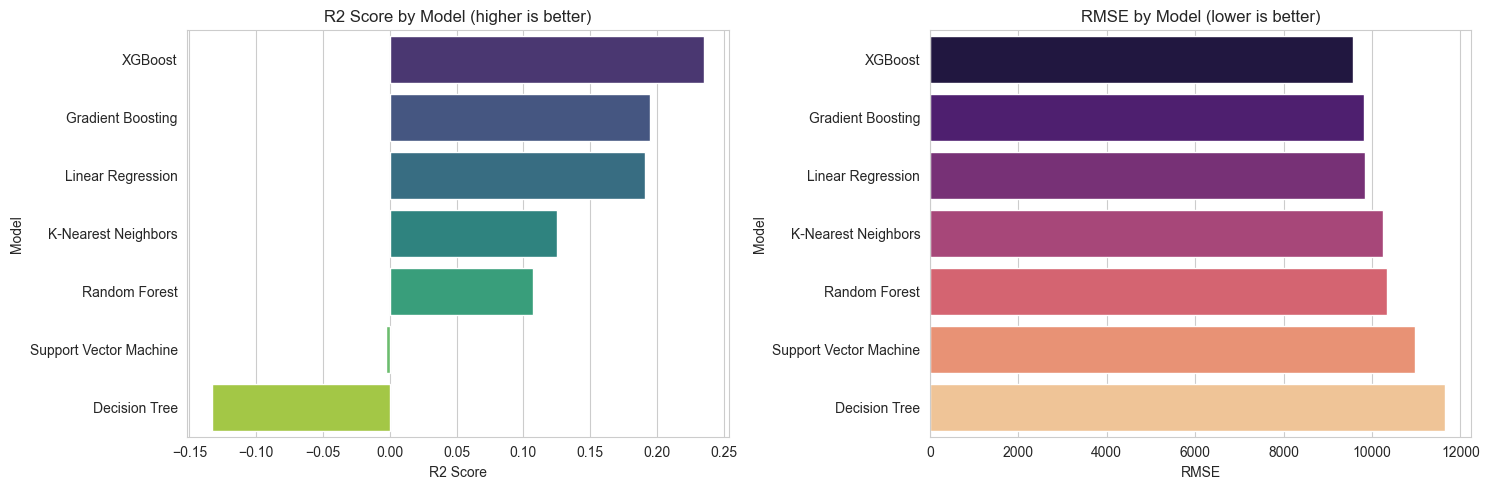

Best performing model based on R2 Score: XGBoost


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=results_df, x='R2 Score', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('R2 Score by Model (higher is better)')

sns.barplot(data=results_df, x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('RMSE by Model (lower is better)')

plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print('Best performing model based on R2 Score:', best_model_name)

## 12. Hyperparameter Tuning

**Why tuning is needed:** every model has hyperparameters (settings chosen before training, like the number of trees or tree depth) that are not learned from the data automatically. The default values are rarely optimal for a specific dataset. Tuning searches over different combinations of these settings to find the ones that produce the best predictive performance, helping the model generalize better to unseen data instead of underfitting or overfitting.

We use **`RandomizedSearchCV`**, which samples a fixed number of random hyperparameter combinations rather than testing every possible combination (as `GridSearchCV` would). This makes tuning much faster on larger datasets while still finding strong hyperparameter settings, using 3-fold cross-validation to evaluate each combination.

We tune the best-performing model type identified above (a tree-based ensemble model).

In [18]:
tuning_candidates = {
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE), {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [2, 3, 4, 5]
    })
}

if XGBOOST_AVAILABLE:
    tuning_candidates['XGBoost'] = (XGBRegressor(random_state=RANDOM_STATE, verbosity=0), {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 5, 6]
    })

tune_target = best_model_name if best_model_name in tuning_candidates else list(tuning_candidates.keys())[0]
base_model, param_grid = tuning_candidates[tune_target]

tuning_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', base_model)])

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print('Model tuned:', tune_target)
print('Best parameters found:', random_search.best_params_)
print('Best cross-validated R2 score:', random_search.best_score_)

Model tuned: XGBoost
Best parameters found: {'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Best cross-validated R2 score: 0.2482284436975838


## 13. Feature Importance

Tree-based models can report how much each feature contributed to reducing prediction error. This helps us interpret *why* the model makes the predictions it does, which is valuable for understanding the underlying pay structure.

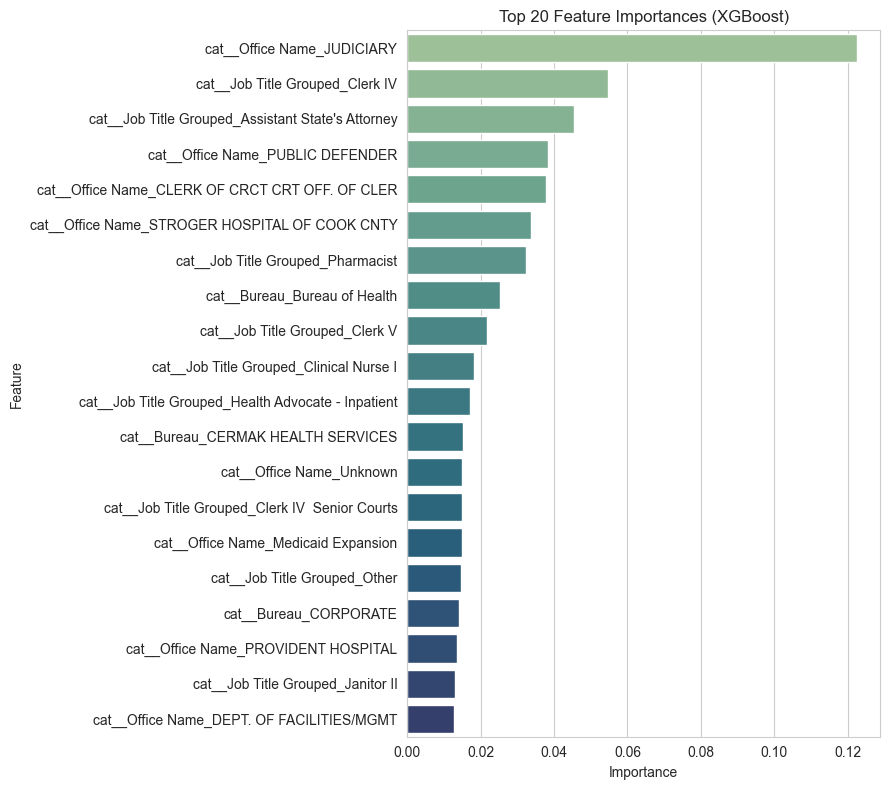

The most influential features are shown above. Features related to specific job titles and bureaus tend to dominate, since job role is usually the strongest driver of pay, followed by tenure and fiscal year.


In [19]:
best_estimator = random_search.best_estimator_
model_step = best_estimator.named_steps['model']

feature_names = best_estimator.named_steps['preprocessor'].get_feature_names_out()

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(9, 8))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
    plt.title(f'Top 20 Feature Importances ({tune_target})')
    plt.tight_layout()
    plt.show()

    print('The most influential features are shown above. Features related to specific job titles and bureaus tend to dominate, since job role is usually the strongest driver of pay, followed by tenure and fiscal year.')
else:
    print('The selected model does not expose feature_importances_.')

## 14. Final Model

We now take the tuned pipeline (best hyperparameters found by `RandomizedSearchCV`) and confirm its performance on the held-out test set. This is our final candidate model.

Final Model: XGBoost
MAE:  4971.86
MSE:  91672846.60
RMSE: 9574.59
R2:   0.2358


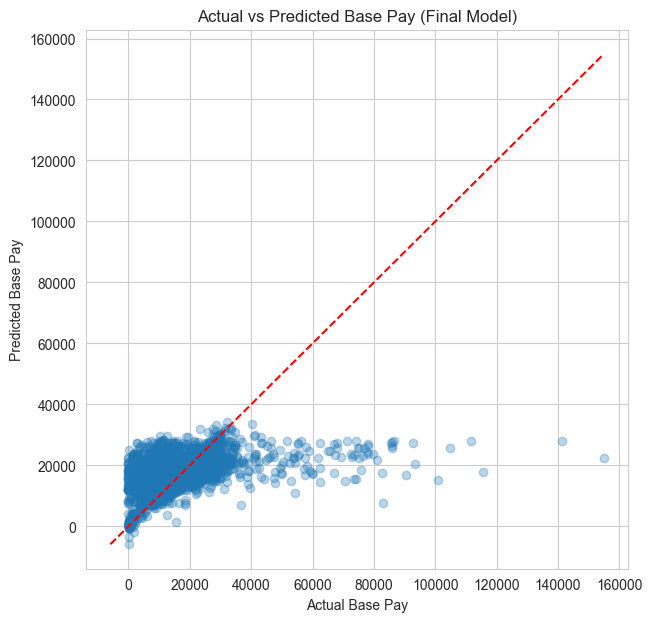

In [20]:
final_pipeline = random_search.best_estimator_
y_pred_final = final_pipeline.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print('Final Model:', tune_target)
print('MAE:  {:.2f}'.format(final_mae))
print('MSE:  {:.2f}'.format(final_mse))
print('RMSE: {:.2f}'.format(final_rmse))
print('R2:   {:.4f}'.format(final_r2))

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final, alpha=0.3)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.xlabel('Actual Base Pay')
plt.ylabel('Predicted Base Pay')
plt.title('Actual vs Predicted Base Pay (Final Model)')
plt.show()

## 15. Model Saving

We save the entire trained pipeline (preprocessing + model) using **Joblib**, so it can be reloaded later without retraining. We then demonstrate loading it back and using it to predict `Base Pay` for a new, unseen employee record.

In [21]:
model_filename = 'employee_payroll_best_model.pkl'
joblib.dump(final_pipeline, model_filename)
print('Model saved to:', model_filename)

loaded_pipeline = joblib.load(model_filename)
print('Model loaded successfully.')

new_employee = pd.DataFrame([{
    'Fiscal Year': 2019,
    'Fiscal Quarter': 2,
    'Tenure': 5,
    'Bureau': 'Sheriff',
    'Office Name': df_clean['Office Name'].mode()[0],
    'Job Title Grouped': 'Correctional Officer'
}])

predicted_pay = loaded_pipeline.predict(new_employee)
print('Predicted Base Pay for new employee record: {:.2f}'.format(predicted_pay[0]))

Model saved to: employee_payroll_best_model.pkl
Model loaded successfully.
Predicted Base Pay for new employee record: 15490.07


## 16. Final Summary

**Dataset overview:** the Employee Payroll dataset contains over 230,000 quarterly pay records for Cook County employees, including fiscal year/quarter, bureau, office, job title, base pay, and original hire date.

**Key EDA findings:** base pay is right-skewed with a small number of very high earners; pay levels vary substantially by bureau and especially by job title, which showed the clearest separation between low- and high-paying roles.

**Data preprocessing performed:** rows with missing or negative `Base Pay` were removed; identifier columns (names, employee ID, position ID) were dropped since they don't generalize; missing numeric and categorical values were imputed; numeric features were scaled and categorical features were one-hot encoded via a `ColumnTransformer`.

**Feature engineering:** derived a `Tenure` feature from the fiscal year and original hire date, and grouped rare job titles into an `"Other"` category to control categorical cardinality.

**Best-performing model:** the tuned tree-based ensemble model identified in Sections 10-12 above (see the printed `best_model_name` / `tune_target` output for the exact algorithm), selected after comparing Linear Regression, Decision Tree, Random Forest, K-Nearest Neighbors, SVM, Gradient Boosting, and (where available) XGBoost.

**Evaluation results:** see the final MAE, MSE, RMSE, and R² printed in Section 14 above, and the actual-vs-predicted scatter plot, which shows how closely predictions track true base pay.

**Model limitations:** the model was trained on a random sample of the full dataset for speed, so results on the complete 230K+ record dataset may differ slightly; it also relies on categorical grouping of job titles, meaning very rare job titles are treated generically as `"Other"`; and it does not account for external factors like promotions, union contract changes, or cost-of-living adjustments that could affect pay over time.

**Possible future improvements:** train on the full dataset rather than a sample, engineer additional features (e.g., years until next fiscal year, department-level average pay), try additional model families (e.g., neural networks), and use more exhaustive hyperparameter search (`GridSearchCV` or Bayesian optimization) given more computation time.